# Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from model_utils import calculate_metrics, evaluate_baselines, update_model_result

# Funções

In [19]:
def apresentar_estacionariedade(serie, log=True):
    resultado_adf = adfuller(serie)
    resultado_kpss = kpss(serie)
    estacionario = (resultado_adf[1] <= 0.05) and (resultado_kpss[1] > 0.05)
    if (log):
        print("="*40)
        print("Estatística ADF:", resultado_adf[0])
        print("p-valor ADF:", resultado_adf[1])
        print("p-valor KPSS:", resultado_kpss[1])
        print("É estacionário?", "Sim" if estacionario else "Não") # Se for menor igual a 0.05 significa que é estacionário
        print("Valores críticos:")
        for chave, valor in resultado_adf[4].items():
            print(f"    {chave}: {valor}")
    return estacionario
    

In [20]:
def tornar_estacionario(serie, target_column):
    diferenciacao = 0
    while not apresentar_estacionariedade(serie[target_column], False):
        diferenciacao += 1
        serie = serie.diff().dropna()
    
    return serie, diferenciacao

In [21]:
def analisar_series_temporais(df, coluna_data, figsize=(14, 5)):
    """
    Plota todas as colunas numéricas ao longo do tempo
    e gera uma matriz de correlação.

    Parameters
    ----------
    df : pandas.DataFrame
    coluna_data : str
        Nome da coluna de data.
    """

    if coluna_data not in df.columns:
        raise ValueError(f"Coluna '{coluna_data}' não encontrada.")

    # Cópia para evitar alterar o dataframe original
    df_plot = df.copy()

    # Conversão para datetime
    df_plot[coluna_data] = pd.to_datetime(df_plot[coluna_data])

    # Ordenação temporal
    df_plot = df_plot.sort_values(coluna_data)

    # Seleciona colunas numéricas
    colunas_numericas = df_plot.select_dtypes(include=np.number).columns

    # Plota cada série temporal
    for coluna in colunas_numericas:
        plt.figure(figsize=figsize)

        plt.plot(
            df_plot[coluna_data],
            df_plot[coluna]
        )

        plt.title(f"{coluna} ao longo do tempo")
        plt.xlabel(coluna_data)
        plt.ylabel(coluna)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Correlação
    correlacao = df_plot[colunas_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Matriz de Correlação")
    plt.tight_layout()
    plt.show()

    return correlacao

In [22]:
def calcular_vif(df, colunas=None):
    """
    Calcula o Variance Inflation Factor (VIF) para as colunas informadas.

    Parameters
    ----------
    df : pandas.DataFrame
    colunas : list[str], optional
        Colunas a serem consideradas. Se None, utiliza todas as numéricas.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo Feature e VIF.
    """

    if colunas is None:
        colunas = df.select_dtypes(include=np.number).columns.tolist()

    X = df[colunas].copy()

    # Remove linhas com NaN
    X = X.dropna()

    vif_df = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Pegando dados

In [34]:
df_raw = pd.read_csv("data/Pilgrim_s_Pride_Corporation_2.csv")
TARGET = "Close"
DATE_COLUMN = "Date"
SEASONAL_PERIOD = 76

df_raw[DATE_COLUMN] = pd.to_datetime(
    df_raw[DATE_COLUMN], errors="coerce", utc=True
).dt.tz_localize(None)
df_raw = df_raw.dropna(subset=[DATE_COLUMN])
df_raw = df_raw.loc[df_raw[DATE_COLUMN] >= pd.Timestamp("2013-01-01")].copy()
df_raw = (
    df_raw.set_index(DATE_COLUMN)
    .sort_index()
    .drop(columns=["Open", "High", "Low", "Volume", "USD_MXN"], errors="ignore")
)

test_size = int(len(df_raw) * 0.25)
train_original = df_raw[TARGET].iloc[:-test_size]
test_original = df_raw[TARGET].iloc[-test_size:]

print(f"Treino: {len(train_original)} observações | Teste: {len(test_original)} observações")

Treino: 2573 observações | Teste: 857 observações


# Separar treino e teste e escalonando

In [35]:
h = len(test_original)
train = train_original
test = test_original
print(f"Horizonte de teste: {h} observações")

Horizonte de teste: 857 observações


# Modelos

## Aditivo

In [36]:
hw_add = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="heuristic"
).fit()

print(f"AIC (Holt-Winters aditivo): {hw_add.aic:.2f}")
print(f"BIC (Holt-Winters aditivo): {hw_add.bic:.2f}")

AIC (Holt-Winters aditivo): -4085.40
BIC (Holt-Winters aditivo): -3617.17


## Multiplicativo

In [37]:
deslocamento_treino = max(0.0, -float(train.min()) + 1e-6)
train_multiplicativo = train + deslocamento_treino

hw_mul = ExponentialSmoothing(
    train_multiplicativo,
    trend="add",
    seasonal="mul",
    seasonal_periods=SEASONAL_PERIOD,
    initialization_method="heuristic"
).fit()

print(f"Deslocamento estimado no treino: {deslocamento_treino:.6f}")
print(f"AIC (Holt-Winters multiplicativo): {hw_mul.aic:.2f}")
print(f"BIC (Holt-Winters multiplicativo): {hw_mul.bic:.2f}")

Deslocamento estimado no treino: 0.000000
AIC (Holt-Winters multiplicativo): -3987.34
BIC (Holt-Winters multiplicativo): -3519.11


Walk-forward: refit a cada 50 observações
Métricas Holt-Winters aditivo: {'mae': 2.376113878969338, 'rmse': 3.0764841380309234, 'mape': 7.094180848791319, 'smape': 7.014523990686573, 'wape': 6.965795361603222}
Métricas Holt-Winters multiplicativo: {'mae': 2.5140204733859277, 'rmse': 3.3848774287663153, 'mape': 7.423281502959964, 'smape': 7.343860215762538, 'wape': 7.370081168030253}
Baselines: {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}


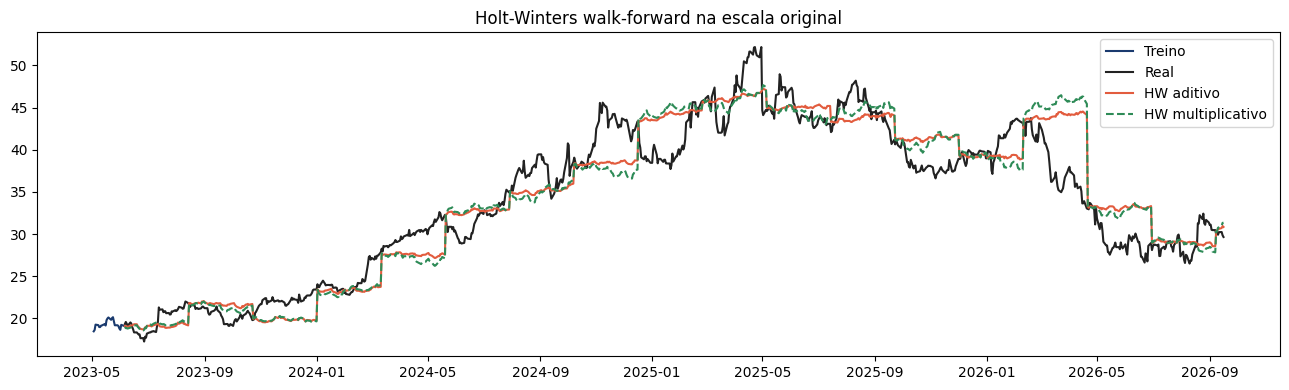

In [41]:
WALK_FORWARD_STEP = 50

# Avaliação walk-forward com refit periódico e janela expansiva.
previsoes_add_walk = []
previsoes_mul_walk = []
historico_add = train_original.copy()
historico_mul = train_original.copy()
for inicio in range(0, len(test_original), WALK_FORWARD_STEP):
    fim = min(inicio + WALK_FORWARD_STEP, len(test_original))
    tamanho_bloco = fim - inicio

    modelo_add_wf = ExponentialSmoothing(
        historico_add, trend="add", seasonal="add",
        seasonal_periods=SEASONAL_PERIOD, initialization_method="heuristic"
    ).fit()
    previsoes_add_walk.extend(modelo_add_wf.forecast(tamanho_bloco).to_numpy())
    historico_add = pd.concat([historico_add, test_original.iloc[inicio:fim]])

    deslocamento_wf = max(0.0, -float(historico_mul.min()) + 1e-6)
    modelo_mul_wf = ExponentialSmoothing(
        historico_mul + deslocamento_wf, trend="add", seasonal="mul",
        seasonal_periods=SEASONAL_PERIOD, initialization_method="heuristic"
    ).fit()
    previsoes_mul_walk.extend(
        (modelo_mul_wf.forecast(tamanho_bloco) - deslocamento_wf).to_numpy()
    )
    historico_mul = pd.concat([historico_mul, test_original.iloc[inicio:fim]])

fc_add = pd.Series(previsoes_add_walk, index=test_original.index)
fc_mul = pd.Series(previsoes_mul_walk, index=test_original.index)
metrics_hw_add = calculate_metrics(test_original, fc_add)
metrics_hw_mul = calculate_metrics(test_original, fc_mul)
baselines_hw = evaluate_baselines(train_original, test_original, SEASONAL_PERIOD)

print("Walk-forward: refit a cada", WALK_FORWARD_STEP, "observações")
print("Métricas Holt-Winters aditivo:", metrics_hw_add)
print("Métricas Holt-Winters multiplicativo:", metrics_hw_mul)
print("Baselines:", baselines_hw)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_original[-24:].index, train_original[-24:], label="Treino", color="#1a3a6e")
ax.plot(test_original.index, test_original, label="Real", color="#222")
ax.plot(fc_add.index, fc_add, label="HW aditivo", color="#e25c3e")
ax.plot(fc_mul.index, fc_mul, "--", label="HW multiplicativo", color="#2e8b57")
ax.set_title("Holt-Winters walk-forward na escala original")
ax.legend()
plt.tight_layout()
plt.show()

## Análise dos parâmetros

Parâmetros estimados (Holt-Winters multiplicativo):
  smoothing_level      = 0.0099
  smoothing_trend      = 0.0024
  smoothing_seasonal   = 0.0702


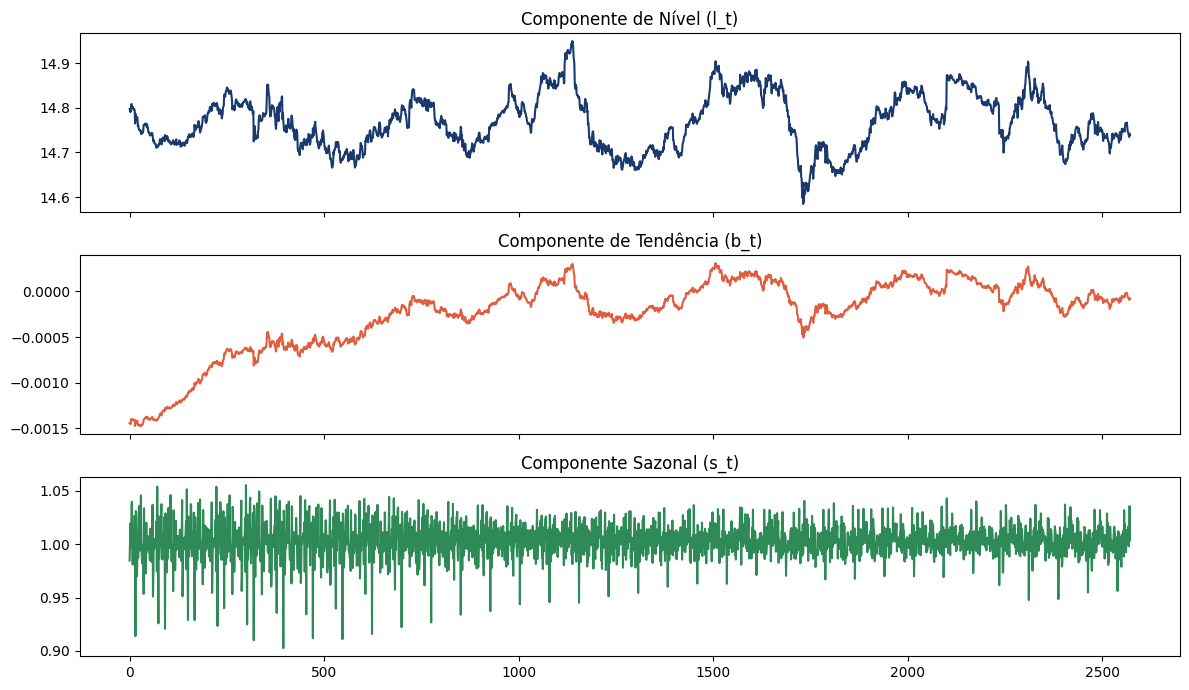

In [28]:
params = hw_mul.params
print("Parâmetros estimados (Holt-Winters multiplicativo):")
for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]:
    print(f"  {nome:<20} = {params[nome]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(train.index, hw_mul.level, color='#1a3a6e')
axes[0].set_title('Componente de Nível (l_t)')
axes[1].plot(train.index, hw_mul.trend, color='#e25c3e')
axes[1].set_title('Componente de Tendência (b_t)')
axes[2].plot(train.index, hw_mul.season, color='#2e8b57')
axes[2].set_title('Componente Sazonal (s_t)')
plt.tight_layout()
plt.show()

## Resíduo

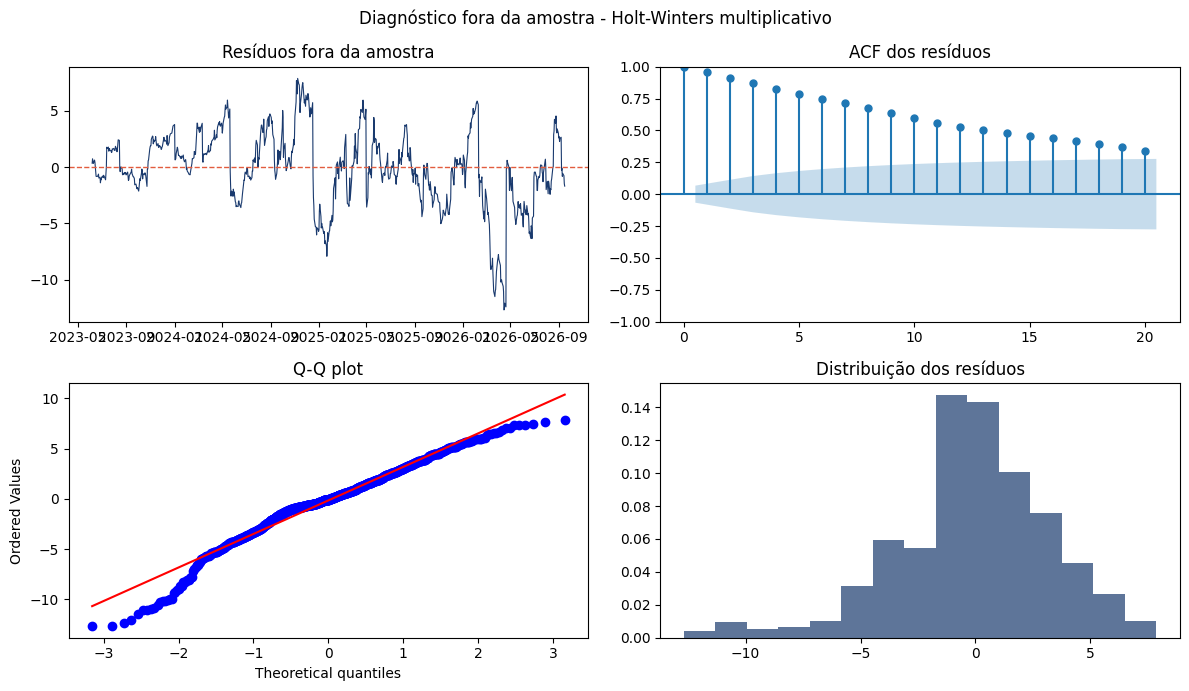

Métricas multiplicativas: {'mae': 2.5140204733859277, 'rmse': 3.3848774287663153, 'mape': 7.423281502959964, 'smape': 7.343860215762538, 'wape': 7.370081168030253}
Ljung-Box:


,lb_stat,lb_pvalue
1,792.0258,0.0
2,1514.3235,0.0
3,2167.4060,0.0
4,2758.1206,0.0
5,3294.1724,0.0
6,3779.4081,0.0
7,4219.8860,0.0
8,4614.3717,0.0
9,4964.9684,0.0
10,5275.0575,0.0


Resíduos sem autocorrelação nos lags avaliados: False


In [43]:
resid = (test_original - fc_mul).dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(resid.index, resid, color="#1a3a6e", linewidth=0.8)
axes[0, 0].axhline(0, color="#e25c3e", linewidth=1, linestyle="--")
axes[0, 0].set_title("Resíduos fora da amostra")
plot_acf(resid, lags=min(20, len(resid) - 2), ax=axes[0, 1], title="ACF dos resíduos")
stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot")
axes[1, 1].hist(resid, bins=15, density=True, color="#1a3a6e", alpha=0.7)
axes[1, 1].set_title("Distribuição dos resíduos")
plt.suptitle("Diagnóstico fora da amostra - Holt-Winters multiplicativo")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=min(12, len(resid) // 5), return_df=True)
todos_ok = bool((lb["lb_pvalue"] > 0.05).all())
print("Métricas multiplicativas:", metrics_hw_mul)
print("Ljung-Box:")
display(lb[["lb_stat", "lb_pvalue"]].round(4))
print("Resíduos sem autocorrelação nos lags avaliados:", todos_ok)

## Importância das variáveis

O Holt-Winters é um modelo univariado: utiliza somente a série `Close` e seus componentes de nível, tendência e sazonalidade. Portanto, não existem variáveis explicativas para calcular feature importance. Os parâmetros de suavização abaixo são apresentados como diagnóstico do ajuste, e não como importância de features.

O Holt-Winters não possui features exógenas; SHAP será aplicado aos componentes do ajuste por meio de um surrogate linear.
Importância SHAP dos componentes do Holt-Winters:


,mean_abs_shap
nivel,3.441704
sazonalidade,0.284083
tendencia,0.029441


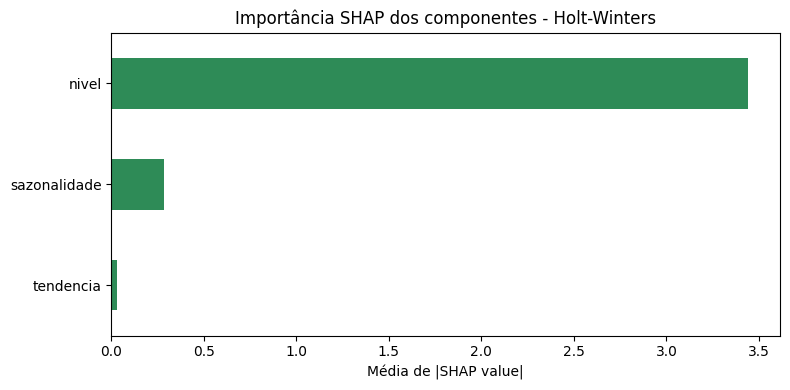

In [42]:
import shap
from sklearn.linear_model import LinearRegression

print("O Holt-Winters não possui features exógenas; SHAP será aplicado aos componentes do ajuste por meio de um surrogate linear.")
componentes = pd.DataFrame({
    "nivel": hw_mul.level,
    "tendencia": hw_mul.trend,
    "sazonalidade": hw_mul.season
}).dropna()
fitted = hw_mul.fittedvalues.reindex(componentes.index)
surrogate = LinearRegression().fit(componentes, fitted)
explainer_shap = shap.LinearExplainer(surrogate, componentes)
shap_values = explainer_shap(componentes)
importancias_shap_hw = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=componentes.columns
).sort_values(ascending=False)
print("Importância SHAP dos componentes do Holt-Winters:")
display(importancias_shap_hw.rename("mean_abs_shap").to_frame())
plt.figure(figsize=(8, 4))
importancias_shap_hw.sort_values().plot(kind="barh", color="#2e8b57")
plt.title("Importância SHAP dos componentes - Holt-Winters")
plt.xlabel("Média de |SHAP value|")
plt.tight_layout()
plt.show()

In [44]:
params_add = {
    nome: float(hw_add.params[nome])
    for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]
}
params_mul = {
    nome: float(hw_mul.params[nome])
    for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]
}

resultado_add = update_model_result(
    "all_modelos.json",
    "HoltWintersAditivo",
    metrics_hw_add,
    params=params_add,
    extra={
        "baselines": baselines_hw,
        "walk_forward_step": WALK_FORWARD_STEP,
        "shap_importance": importancias_shap_hw.head(20).to_dict()
    }
)
resultado_mul = update_model_result(
    "all_modelos.json",
    "HoltWintersMultiplicativo",
    metrics_hw_mul,
    params=params_mul,
    extra={
        "baselines": baselines_hw,
        "walk_forward_step": WALK_FORWARD_STEP,
        "deslocamento_treino": deslocamento_treino,
        "shap_importance": importancias_shap_hw.head(20).to_dict()
    }
)
print(resultado_add)
print(resultado_mul)

{'modelo': 'HoltWintersAditivo', 'mae': 2.376113878969338, 'rmse': 3.0764841380309234, 'mape': 7.094180848791319, 'smape': 7.014523990686573, 'wape': 6.965795361603222, 'params': {'smoothing_level': 0.9577537364875919, 'smoothing_trend': 0.0006212404677988752, 'smoothing_seasonal': 0.04224626351240812}, 'baselines': {'naive': {'mae': 15.032457984830806, 'rmse': 17.409610930895454, 'mape': 39.643745639959135, 'smape': 52.23992173142592, 'wape': 44.06902675458048}, 'seasonal_naive': {'mae': 14.688274061843641, 'rmse': 17.06490497779233, 'mape': 38.70747756294008, 'smape': 50.6694518891883, 'wape': 43.060020075438345}}, 'walk_forward_step': 50, 'shap_importance': {'nivel': 3.4417036841541275, 'sazonalidade': 0.28408326286246266, 'tendencia': 0.02944146585960071}}
{'modelo': 'HoltWintersMultiplicativo', 'mae': 2.5140204733859277, 'rmse': 3.3848774287663153, 'mape': 7.423281502959964, 'smape': 7.343860215762538, 'wape': 7.370081168030253, 'params': {'smoothing_level': 0.9454767065499113, 's